In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import connect_to_db, execute_query, extract_hour_day, calculate_phase_durations, calculate_flight_duration, calculate_total_distance, calculate_phase_distance, vectorized_haversine, haversine
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import INTERIM_DATA_DIR
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
pd.set_option('display.max_columns', None)
cnn = connect_to_db()
initial_data = pd.read_csv(os.path.join(INTERIM_DATA_DIR, "initial_dataset.csv"))
data = initial_data.copy()

datetime format

In [3]:
data['ATOT_track'] = pd.to_datetime(data['ATOT_track'])
data['ALDT_track'] = pd.to_datetime(data['ALDT_track'])

phase_times_cols = ['dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT']
for col in phase_times_cols:
    data[col] = pd.to_datetime(data[col])

set correct end_climb and start_descent

In [4]:
data['takeoff_diff'] = abs((data['dtPhaseStart_CLIMB'] - data['ATOT_track']).dt.total_seconds() / 3600)
data['landing_diff'] = abs((data['ALDT_track'] - data['dtPhaseEnd_DESCENT']).dt.total_seconds() / 3600)

data['dtPhaseStart_CLIMB'] = data['dtPhaseStart_CLIMB'].mask(data['takeoff_diff'] > 0.5, np.nan) # 30 min difference
data['dtPhaseEnd_DESCENT'] = data['dtPhaseEnd_DESCENT'].mask(data['landing_diff'] > 0.5, np.nan)

data['dtPhaseEnd_CLIMB'] = data['dtPhaseEnd_CLIMB'].mask(data['dtPhaseStart_CLIMB'].isna(), np.nan) 
data['dtPhaseStart_DESCENT'] = data['dtPhaseStart_DESCENT'].mask(data['dtPhaseEnd_DESCENT'].isna(), np.nan)

data['dtPhaseStart_CLIMB'] = data['dtPhaseStart_CLIMB'].fillna(data['ATOT_track'])
data['dtPhaseEnd_DESCENT'] = data['dtPhaseEnd_DESCENT'].fillna(data['ALDT_track'])

# calculate again to compare
data['takeoff_diff'] = abs((data['dtPhaseStart_CLIMB'] - data['ATOT_track']).dt.total_seconds() / 3600)
data['landing_diff'] = abs((data['ALDT_track'] - data['dtPhaseEnd_DESCENT']).dt.total_seconds() / 3600)

set correct start_cruise and end_cruise

In [5]:
data['dtPhaseStart_CRUISE'] = data['dtPhaseStart_CRUISE'].mask(data['dtPhaseEnd_CLIMB'].isna(), np.nan)
data['dtPhaseEnd_CRUISE'] = data['dtPhaseEnd_CRUISE'].mask(data['dtPhaseStart_DESCENT'].isna(), np.nan)

order columns for visualization

In [6]:
phase_times_cols = ['dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT']
remaining_columns = [col for col in data.columns if col not in phase_times_cols]
ordered_columns = remaining_columns + phase_times_cols
data = data[ordered_columns]

remove flights without trace points

In [7]:
# flights_wo_trace = []
# for flight_id in data['flightKey']:
#     df = execute_query(cnn, flight_id)
#     if df.empty:
#         flights_wo_trace.append(flight_id)
data = data[~data['flightKey'].isin([18709432, 19994755, 19936534])]

# hour and day of the year from ATOT and ALDT

In [8]:
data = extract_hour_day(data, 'ATOT_track')
data = extract_hour_day(data, 'ALDT_track')

# flight duration

In [9]:
data = calculate_flight_duration(data)

# phases duration

calculate phase durations with no-nan start_phase and end_phase

In [10]:
data = calculate_phase_durations(data)

set end_climb and start_descent with medians of each phase

In [11]:
# for CLIMB phase
median_duration = data.groupby('wake')['CLIMB_duration'].transform('median')
median_duration = pd.to_timedelta(median_duration, unit='h')  
data['dtPhaseEnd_CLIMB'] = data['dtPhaseEnd_CLIMB'].fillna(data['dtPhaseStart_CLIMB'] + median_duration)

In [12]:
# for DESCENT phase
median_duration = data.groupby('wake')['DESCENT_duration'].transform('median')
median_duration = pd.to_timedelta(median_duration, unit='h')  
data['dtPhaseStart_DESCENT'] = data['dtPhaseStart_DESCENT'].fillna(data['dtPhaseEnd_DESCENT'] - median_duration)

calculate again phase duration for missing durations of climb and descent

In [13]:
data = calculate_phase_durations(data)

calculate cruise duration with flight_duration and other two phases duration

In [14]:
data['CRUISE_duration'] = data['CRUISE_duration'].fillna(data['flight_duration'] - data['CLIMB_duration'] - data['DESCENT_duration'])

In [15]:
data['dtPhaseStart_CRUISE'] = data['dtPhaseEnd_CLIMB']
data['dtPhaseEnd_CRUISE'] = data['dtPhaseStart_DESCENT']

climb phase duration >= 1.5 hours

In [94]:
# data[data['CLIMB_duration'] >= 1.5][['flightKey', 'adep', 'ades', 'routeType', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'flight_duration']]

descent phase duration >= 1.5 hours

In [95]:
# data[data['DESCENT_duration'] > 1.5][['flightKey', 'adep', 'ades', 'routeType', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'flight_duration']]

distribution plot of each phase duration

In [97]:
# plt.figure(figsize=(10, 6))
# ax = plt.gca()
# sns.histplot(data['flight_duration'], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel('Duration (hours)')
# plt.ylabel('Number of flights')
# # plt.axis([0, 2, 0, 50000])
# plt.title('Distribution of overall flight duration.')
# plt.show()

In [98]:
# plt.figure(figsize=(10, 6))
# ax = plt.gca()
# sns.histplot(data['CLIMB_duration'], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel('Duration (hours)')
# plt.ylabel('Number of flights')
# # plt.axis([0, 2, 0, 60000])
# plt.title('Distribution of CLIMB duration.')
# plt.show()

In [99]:
# plt.figure(figsize=(10, 6))
# ax = plt.gca()
# sns.histplot(data['CRUISE_duration'], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel('Duration (hours)')
# plt.ylabel('Number of flights')
# # plt.axis([0, 2, 0, 50000])
# plt.title('Distribution of CRUISE duration.')
# plt.show()

In [100]:
# plt.figure(figsize=(10, 6))
# ax = plt.gca()
# sns.histplot(data['DESCENT_duration'], bins=50, edgecolor='black', stat='count', kde=True)
# plt.xlabel('Duration (hours)')
# plt.ylabel('Number of flights')
# # plt.axis([0, 2, 0, 50000])
# plt.title('Distribution of DESCENT duration.')
# plt.show()

# validate if phases duration is correct

In [22]:
data['total_dur_phases'] = data['CLIMB_duration'] + data['CRUISE_duration'] + data['DESCENT_duration']
data['total_dur_diff'] = data['flight_duration'] - data['total_dur_phases']

total_dur_phases > flight_duration

In [101]:
# data[data['total_dur_diff'] <= -0.125][['adep', 'ades', 'flightKey', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'flight_duration', 'total_dur_phases']]

total_dur_phases < flight_duration

In [102]:
# data[data['total_dur_diff'] >= 0.25][['adep', 'ades', 'flightKey', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'flight_duration', 'total_dur_phases', 'total_dur_diff']]

In [25]:
print('max_duration diff:', abs(data['total_dur_diff']).max())
print('0 to 7.5 minutes diff:', len(data[(abs(data['total_dur_diff']) >= 0) & (abs(data['total_dur_diff']) < 0.125)]))
print('7.5 to 15 minutes diff:', len(data[(abs(data['total_dur_diff']) >= 0.125) & (abs(data['total_dur_diff']) < 0.25)])) 
print('15 to 30 minutes diff:', len(data[(abs(data['total_dur_diff']) >= 0.25) & (abs(data['total_dur_diff']) < 0.5)]))
print('more than 30 minutes diff:', len(data[(abs(data['total_dur_diff']) >= 0.5)]))

max_duration diff: 0.5080555555555556
0 to 7.5 minutes diff: 44891
7.5 to 15 minutes diff: 2
15 to 30 minutes diff: 1
more than 30 minutes diff: 1


# validate total distance

In [37]:
# from tqdm import tqdm

# data[['total_distance', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance']] = np.nan

# for flight_id in tqdm(data['flightKey'], desc="Processing flight distances"):
#     query_df = execute_query(cnn, flight_id)
#     total_distance = calculate_total_distance(data, flight_id, query_df)
#     phase_distances = calculate_phase_distance(data, flight_id, query_df)
    
#     data.loc[data['flightKey'] == flight_id, ['total_distance', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance']] = (
#         total_distance,
#         phase_distances.get('CLIMB_distance', np.nan),
#         phase_distances.get('CRUISE_distance', np.nan),
#         phase_distances.get('DESCENT_distance', np.nan)
#     )
# data.to_csv('data_with_distances.csv', index=False)

In [103]:
data = pd.read_csv("data_with_distances.csv")

In [104]:
data['haversine_dist'] = vectorized_haversine(data['ADEPLat'].values, data['ADEPLong'].values, data['ADESLat'].values, data['ADESLong'].values)

In [105]:
data['total_distance_diff'] = data['total_distance'] - data['haversine_dist']

distribution plot

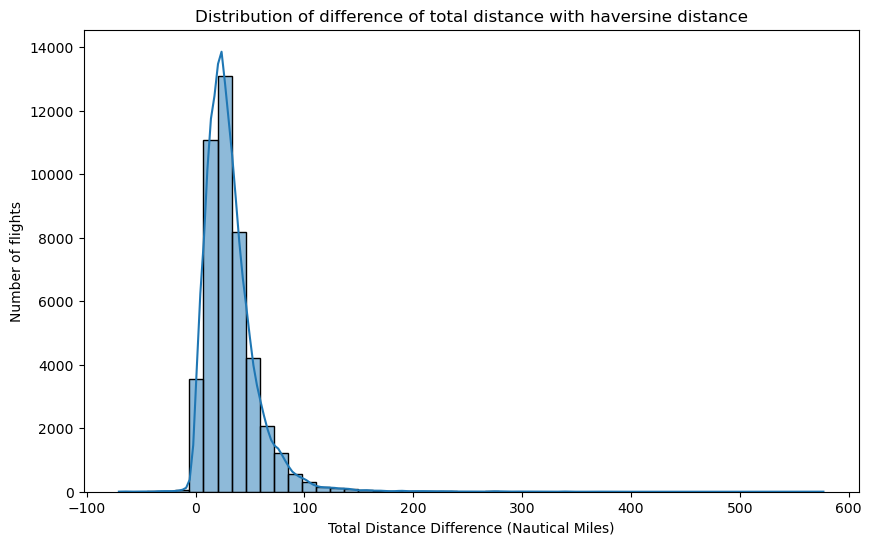

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data['total_distance_diff'], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Total Distance Difference (Nautical Miles)')
plt.ylabel('Number of flights')
plt.title('Distribution of difference of total distance with haversine distance')
plt.show()

In [56]:
data['diff_percentage'] = (data['total_distance_diff'] / data['haversine_dist']) * 100
low_diff_threshold = 10 
low_diff_count = (data['diff_percentage'] < low_diff_threshold).sum()
total_count = data.shape[0]
print(f"Proportion of flights with <{low_diff_threshold}% difference: {low_diff_count / total_count:.2%}")


Proportion of flights with <10% difference: 96.71%


In [ ]:
initial_data[initial_data['flightKey'] == 18176644][['adep', 'ades', 'flightKey', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track']]

,adep,ades,flightKey,ATOT_track,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ALDT_track
9817,LERS,LEGE,18176644,2022-05-01 16:04:00,2022-05-01 16:04:21,2022-05-01 16:09:36,2022-05-01 16:09:36,2022-05-01 16:19:59,2022-05-01 16:19:59,2022-05-01 16:51:19,2022-05-01 16:51:20


In [47]:
data[data['flightKey'] == 18176644][['adep', 'ades', 'flightKey', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'haversine_dist', 'total_distance', 'total_distance_diff']].sort_values(by="total_distance_diff")

,adep,ades,flightKey,ATOT_track,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ALDT_track,haversine_dist,total_distance,total_distance_diff
9817,LERS,LEGE,18176644,2022-05-01 16:04:00,2022-05-01 16:04:21,2022-05-01 16:09:36,2022-05-01 16:09:36,2022-05-01 16:19:59.000000000,2022-05-01 16:19:59.000000000,2022-05-01 16:51:19,2022-05-01 16:51:20,84.705718,191.02563,106.319911


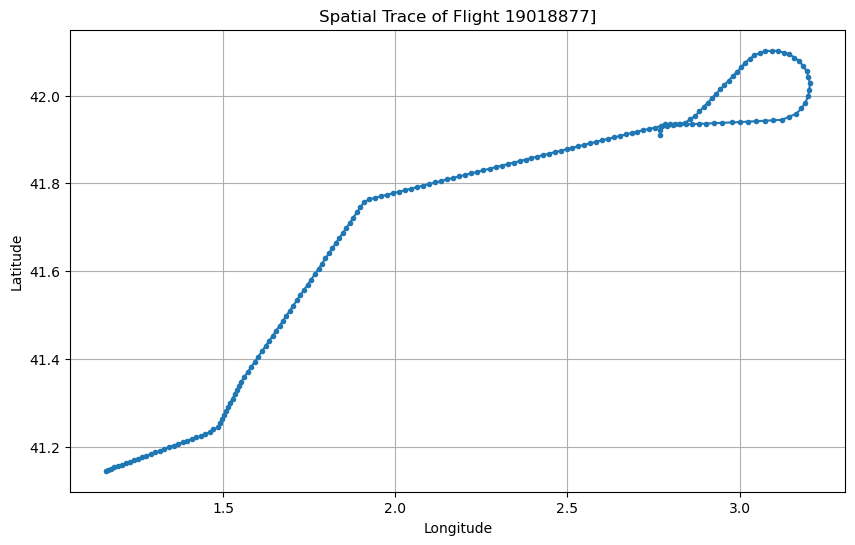

In [58]:
flight_id = 19018877
q = execute_query(cnn, flight_id)

plt.figure(figsize=(10, 6))
# Plot a line connecting the points and add markers
plt.plot(q['lng'], q['lat'], marker='o', linestyle='-', markersize=3)
plt.title(f'Spatial Trace of Flight {flight_id}]')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


In [57]:
low_diff_threshold = 50 
data[data['diff_percentage'] > low_diff_threshold].sort_values(by='diff_percentage')

,flightKey,CFMUflightKey,callsign,adep,ades,ADEPLat,ADEPLong,ADESLat,ADESLong,routeType,aircraftType,aircraftOperator,operatingAircraftOperator,ATOT_track,ALDT_track,airlineCode,tow,flightType,wake,RECATwake,EngineType,Description,numberOfEngines,aircraftNumber,aircraftRegistration,previousAdes,altAdes,cruiseSpeed,cruiseLevel,arrivalRunway,departureRunway,mtow,mlw,oew,mfc,vmo,mmo,ceiling,range,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ATOT_track_hour,ATOT_track_day,ALDT_track_hour,ALDT_track_day,flight_duration,CLIMB_duration,CRUISE_duration,DESCENT_duration,total_distance,CLIMB_distance,CRUISE_distance,DESCENT_distance,haversine_dist,total_distance_diff,diff_percentage
11119,18281578,52759222,BEL1MR,LEVX,LPPR,42.22917,-8.627500,41.23555,-8.678056,INTERNATIONAL,A320,BEL,BEL,2022-05-10 12:34:00,2022-05-10 12:59:50,BEL,57839.19778,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOSND,LPPR,LEVX,359.0,210.0,NaN,01,78000,66000.0,42600,24210.0,350.0,0.82,12500,NaN,2022-05-10 12:34:36,2022-05-10 12:39:46,2022-05-10 12:39:46,2022-05-10 12:49:03.000000000,2022-05-10 12:49:03.000000000,2022-05-10 12:55:28,12,130,12,130,0.430556,0.086111,0.154722,0.106944,89.583186,18.948085,45.277364,45.001941,59.700389,29.882797,50.054611
20587,18787208,53196367,JAF4EK,LEPA,LEIB,39.55167,2.738889,38.87278,1.373056,NATIONAL,B38M,JAF,JAF,2022-07-08 16:44:00,2022-07-08 17:09:46,JAF,61851.00000,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTMY,LEIB,LEPA,308.0,100.0,24,06R,82000,66300.0,45000,26000.0,340.0,0.82,12500,NaN,2022-07-08 16:44:16,2022-07-08 16:49:01,2022-07-08 16:49:01,2022-07-08 16:58:24.000000000,2022-07-08 16:58:24.000000000,2022-07-08 17:10:14,16,189,17,189,0.429444,0.079167,0.156389,0.197222,114.051531,20.821125,47.863859,42.653357,75.487516,38.564014,51.086612
35386,19713704,53810223,SWR561H,LEBB,LFBZ,43.30111,-2.910556,43.46833,-1.531111,INTERNATIONAL,BCS3,SWR,SWR,2022-10-02 09:52:00,2022-10-02 10:15:17,SWR,44907.00000,OTHERS,M,M+,Jet,LandPlane,2.0,1.0,HBJCI,LFBZ,LFSB,338.0,240.0,NaN,30,70900,NaN,37080,NaN,NaN,0.82,12500,6300.0,2022-10-02 09:52:03,2022-10-02 09:57:20,2022-10-02 09:57:20,2022-10-02 10:01:25.000000000,2022-10-02 10:01:25.000000000,2022-10-02 10:15:48,9,275,10,275,0.388056,0.088056,0.068056,0.239722,92.228836,24.119038,20.489299,45.435138,61.022745,31.206091,51.138458
33469,19607262,53734474,JAF7K,LEPA,LEIB,39.55167,2.738889,38.87278,1.373056,NATIONAL,B738,JAF,JAF,2022-09-20 16:39:00,2022-09-20 17:06:18,JAF,62752.00000,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTNB,LEIB,LEPA,325.0,100.0,06,24R,79000,66300.0,41400,26000.0,340.0,0.82,12500,NaN,2022-09-20 16:39:38,2022-09-20 16:43:13,2022-09-20 16:43:13,2022-09-20 16:55:16.000000000,2022-09-20 16:55:16.000000000,2022-09-20 17:06:18,16,263,17,263,0.455000,0.059722,0.200833,0.183889,114.871911,14.558862,58.131827,40.633930,75.487516,39.384395,52.173388
9451,18159120,16110296,JAF7TK,LEMH,LEPA,39.86250,4.218611,39.55167,2.738889,NATIONAL,B38M,JAF,JAF,2022-04-28 16:48:00,2022-04-28 17:11:31,JAF,56835.00000,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTMY,LEPA,LEMH,296.0,100.0,06L,01,82000,66300.0,45000,26000.0,340.0,0.82,12500,NaN,2022-04-28 16:47:14,2022-04-28 16:52:02,2022-04-28 16:52:02,2022-04-28 17:00:07.000000000,2022-04-28 17:00:07.000000000,2022-04-28 17:11:39,16,118,17,118,0.391944,0.080000,0.134722,0.192222,110.663730,19.031018,46.056894,44.438991,70.849943,39.813787,56.194523
24077,19065168,53338319,JAF4EK,LEPA,LEIB,39.55167,2.738889,38.87278,1.373056,NATIONAL,B38M,JAF,JAF,2022-07-29 16:34:00,2022-07-29 17:02:44,JAF,62755.00000,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTMB,LEIB,LEPA,321.0,100.0,06,24R,82000,66300.0,45000,26000.0,340.0,0.82,12500,NaN,2022-07-29 16:34:17,2022-07-29 16:40:54,2022-07-29 16:40:54,2022-07-29 16:46:32.000000000,2022-07-29 16:46:32.000000000,2022-07-29 17:03:09,16,210,17,210,0.478889,0.110278,0.093889,0.276944,118.493958,28.224497,27.005836,60.639286,75.487516,43.006442,56.971595
28470,19357579,53496967,JAF1343,LEIB,

In [59]:
# # flight_id = 20475377
# flight_id = 17507224
# print('haversine distance between airports:', haversine(
#                                         data[data['flightKey'] == flight_id]['ADEPLat'].iloc[0], 
#                                         data[data['flightKey'] == flight_id]['ADEPLong'].iloc[0],
#                                         data[data['flightKey'] == flight_id]['ADESLat'].iloc[0],
#                                         data[data['flightKey'] == flight_id]['ADESLong'].iloc[0]
#                                         ))
# print('estimated total distance:', calculate_total_distance(data, flight_id, execute_query(cnn, flight_id)))
# phases_distances = calculate_phase_distance(data, flight_id, execute_query(cnn, flight_id))
# print('sum of estimated phases distances:', phases_distances['CLIMB_distance'] + phases_distances['CRUISE_distance'] + phases_distances['DESCENT_distance'])
# print(phases_distances)

# validate phases distances

imputing empty distances of CLIMB and DESCENT with median

In [60]:
# for CLIMB phase
median_distance = data.groupby('wake')['CLIMB_distance'].transform('median') # including zeros  
overall_median = data.loc[data['CLIMB_distance'] > 0, 'CLIMB_distance'].median() # excluding zeros
data['CLIMB_distance'] = data['CLIMB_distance'].mask(data['CLIMB_distance'] == 0, median_distance.where(median_distance > 0, overall_median))

In [61]:
# for DESCENT phase
median_distance = data.groupby('wake')['DESCENT_distance'].transform('median') # including zeros  
overall_median = data.loc[data['DESCENT_distance'] > 0, 'DESCENT_distance'].median() # excluding zeros
data['DESCENT_distance'] = data['DESCENT_distance'].mask(data['DESCENT_distance'] == 0, median_distance.where(median_distance > 0, overall_median))

In [62]:
len(data[data['CRUISE_distance'] == 0])

43

In [63]:
data['estimated_cruise_distance'] = data['haversine_dist'] - data['CLIMB_distance'] - data['DESCENT_distance']
data['CRUISE_distance'] = data['CRUISE_distance'].mask(data['CRUISE_distance'] == 0, data['estimated_cruise_distance'])

In [64]:
len(data[data['CRUISE_distance'] == 0])

0

In [65]:
data['CRUISE_distance'] = data['CRUISE_distance'].mask(data['estimated_cruise_distance'] > data['CRUISE_distance'], data['estimated_cruise_distance'])

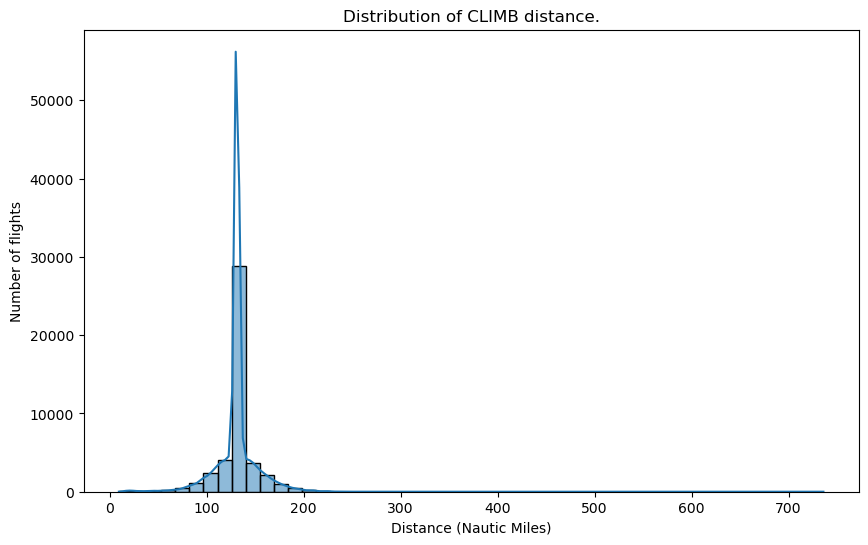

In [66]:
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.histplot(data['CLIMB_distance'], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Distance (Nautic Miles)')
plt.ylabel('Number of flights')
# plt.axis([0, 2, 0, 50000])
plt.title('Distribution of CLIMB distance.')
plt.show()

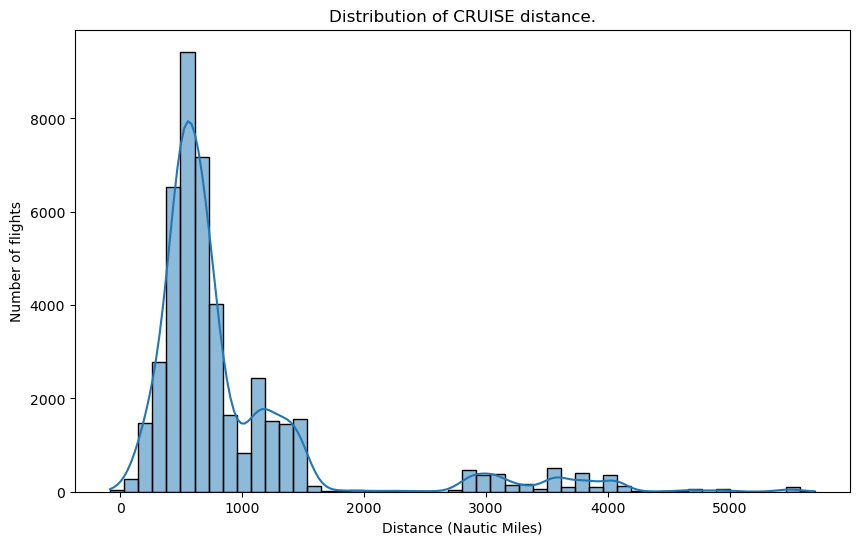

In [67]:
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.histplot(data['CRUISE_distance'], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Distance (Nautic Miles)')
plt.ylabel('Number of flights')
# plt.axis([0, 2, 0, 50000])
plt.title('Distribution of CRUISE distance.')
plt.show()

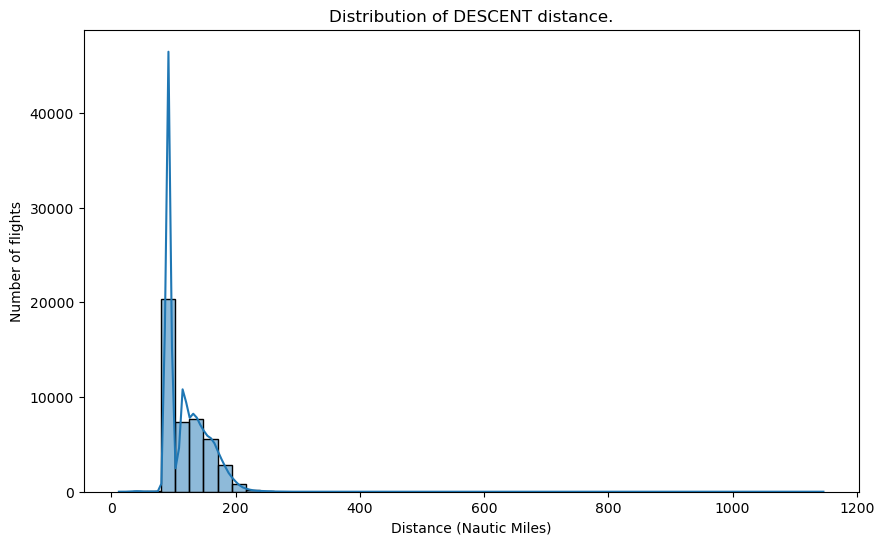

In [68]:
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.histplot(data['DESCENT_distance'], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Distance (Nautic Miles)')
plt.ylabel('Number of flights')
# plt.axis([0, 2, 0, 50000])
plt.title('Distribution of DESCENT distance.')
plt.show()

In [72]:
initial_data[initial_data['flightKey'] == 17520940][['ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track']]

,ATOT_track,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ALDT_track
286,2022-01-04 11:04:00,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:13:55,2022-01-04 11:13:55,2022-01-04 11:24:27,2022-01-04 11:24:41


In [70]:
data[data['flightKey'] == 17520940][['ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track']]

,ATOT_track,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ALDT_track
286,2022-01-04 11:04:00,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:13:55.000000000,2022-01-04 11:13:55.000000000,2022-01-04 11:24:27,2022-01-04 11:24:41


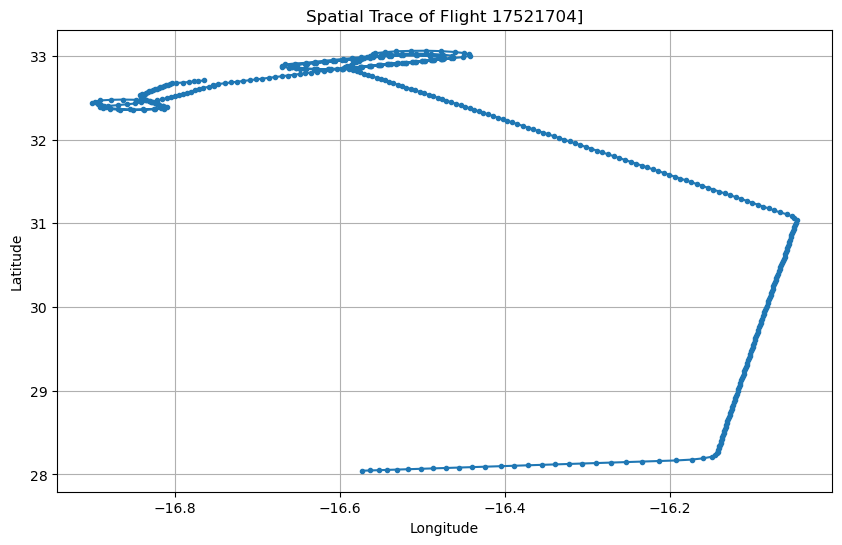

In [77]:
flight_id = 17521704
q = execute_query(cnn, flight_id)

plt.figure(figsize=(10, 6))
# Plot a line connecting the points and add markers
plt.plot(q['lng'], q['lat'], marker='o', linestyle='-', markersize=3)
plt.title(f'Spatial Trace of Flight {flight_id}]')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


In [73]:
data[data['estimated_cruise_distance'] < -20]

,flightKey,CFMUflightKey,callsign,adep,ades,ADEPLat,ADEPLong,ADESLat,ADESLong,routeType,aircraftType,aircraftOperator,operatingAircraftOperator,ATOT_track,ALDT_track,airlineCode,tow,flightType,wake,RECATwake,EngineType,Description,numberOfEngines,aircraftNumber,aircraftRegistration,previousAdes,altAdes,cruiseSpeed,cruiseLevel,arrivalRunway,departureRunway,mtow,mlw,oew,mfc,vmo,mmo,ceiling,range,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ATOT_track_hour,ATOT_track_day,ALDT_track_hour,ALDT_track_day,flight_duration,CLIMB_duration,CRUISE_duration,DESCENT_duration,total_distance,CLIMB_distance,CRUISE_distance,DESCENT_distance,haversine_dist,total_distance_diff,diff_percentage,estimated_cruise_distance
286,17520940,15476259,JAF8DV,LEGR,LEMG,37.18861,-3.777222,36.67500,-4.499166,NATIONAL,E190,JAF,JAF,2022-01-04 11:04:00,2022-01-04 11:24:41,JAF,41852.0,REGULAR,M,M-,Jet,LandPlane,2.0,1.0,OOTEA,LEMG,LEGR,384.0,170.0,12,27,50300,43000.0,27753,16153.0,320.0,0.82,12500,NaN,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:04:23,2022-01-04 11:13:55.000000000,2022-01-04 11:13:55.000000000,2022-01-04 11:24:27,11,4,11,4,0.344722,0.000000,0.158889,0.175556,80.152236,130.930415,40.890338,37.913394,46.383611,33.768625,72.802925,-122.460198
301,17521704,15476419,TUI6KL,GCTS,LPMA,28.04445,-16.572500,32.69417,-16.778060,INTERNATIONAL,B738,TUI,TUI,2022-01-04 13:26:00,2022-01-04 15:07:08,TUI,65843.0,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,DATYA,LPMA,GCTS,432.0,360.0,NaN,07,79000,66300.0,41400,26000.0,340.0,0.82,12500,NaN,2022-01-04 13:26:29,2022-01-04 13:38:49,2022-01-04 13:38:49,2022-01-04 14:02:16.000000000,2022-01-04 14:02:16.000000000,2022-01-04 15:05:46,13,4,15,4,1.685556,0.205556,0.390833,1.058333,505.760417,70.780799,168.868548,265.600345,279.374112,226.386305,81.033387,-57.007032
2047,17642793,15582961,JAF28C,GCTS,LPMA,28.04445,-16.572500,32.69417,-16.778060,INTERNATIONAL,B38M,JAF,JAF,2022-02-05 12:30:00,2022-02-05 13:28:13,JAF,60835.0,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTMZ,LPMA,LPPS,457.0,400.0,NaN,07,82000,66300.0,45000,26000.0,340.0,0.82,12500,NaN,2022-02-05 12:30:40,2022-02-05 12:53:07,2022-02-05 12:53:07,2022-02-05 12:56:10.000000000,2022-02-05 12:56:10.000000000,2022-02-05 13:26:27,12,36,13,36,0.970278,0.374167,0.050833,0.504722,325.016505,135.773740,21.841438,165.776987,279.374112,45.642393,16.337374,-22.176616
2816,17712341,15773932,JAF28C,GCTS,LPMA,28.04445,-16.572500,32.69417,-16.778060,INTERNATIONAL,B38M,JAF,JAF,2022-02-19 13:27:00,2022-02-19 15:00:47,JAF,68859.0,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOTMA,LPMA,GCFV,447.0,370.0,NaN,07,82000,66300.0,45000,26000.0,340.0,0.82,12500,NaN,2022-02-19 13:27:27,2022-02-19 13:46:55,2022-02-19 13:46:55,2022-02-19 14:00:17.000000000,2022-02-19 14:00:17.000000000,2022-02-19 14:59:47,13,50,15,50,1.563056,0.324444,0.222778,0.991667,453.741457,109.928525,96.795407,246.479178,279.374112,174.367345,62.413566,-77.033591
6213,18009667,15975359,TOM9EG,GCTS,LPMA,28.04445,-16.572500,32.69417,-16.778060,INTERNATIONAL,B738,TOM,TOM,2022-04-04 13:41:00,2022-04-04 15:44:11,TOM,66834.0,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,GTUKM,LPMA,GCTS,385.0,240.0,NaN,07,79000,66300.0,41400,26000.0,340.0,0.82,12500,NaN,2022-04-04 13:41:47,2022-04-04 13:55:50,2022-04-04 13:55:50,2022-04-04 14:15:00.000000000,2022-04-04 14:15:00.000000000,2022-04-04 15:45:42,13,94,15,94,2.053056,0.234167,0.319444,1.511667,560.249920,80.391024,139.882637,339.393184,279.374112,280.875808,100.537521,-140.410096
9817,18176644,16128013,JAF1HG,LERS,LEGE,41.14750,1.167222,41.90083,2.760556,NATIONAL,B737,JAF,JAF,2022-05-01 16:04:00,2022-05-01 16:51:20,JAF,46816.0,REGULAR,M,M+,Jet,LandPlane,2.0,1.0,OOJAS,LEGE,LFMP,314.0,180.0,19,25,70000,58600.0,37600,26000.0,340.0,0.82,12500,NaN,2022-05-01 16:04:21,2022-05-01 16:09:36,2022-05-01 16:09:36,2022-05-01 16:19:59.000000000,2022-05-01 16:19:59.000000000,2022-05-01 16:51:19,16,121,16,121,0.788889,0.087500,0.173056,0.522222,191.025630,21.441370,

In [90]:
data['total_dist_phases'] = data['CLIMB_distance'] + data['CRUISE_distance'] + data['DESCENT_distance']
data['total_dist_diff'] = data['total_dist_phases'] - data['haversine_dist']

total_dist_phases > total_dist

In [91]:
data[data['total_distance_diff'] < 0][['flightKey', 'ATOT_track', 'dtPhaseStart_CLIMB', 'dtPhaseEnd_CLIMB', 'dtPhaseStart_CRUISE', 'dtPhaseEnd_CRUISE', 'dtPhaseStart_DESCENT', 'dtPhaseEnd_DESCENT', 'ALDT_track', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance', 'total_distance', 'total_dist_phases', 'total_dist_diff']]

,flightKey,ATOT_track,dtPhaseStart_CLIMB,dtPhaseEnd_CLIMB,dtPhaseStart_CRUISE,dtPhaseEnd_CRUISE,dtPhaseStart_DESCENT,dtPhaseEnd_DESCENT,ALDT_track,CLIMB_distance,CRUISE_distance,DESCENT_distance,total_distance,total_dist_phases,total_dist_diff
18,17507519,2022-01-01 09:47:00,2022-01-01 09:47:00,2022-01-01 10:08:00,2022-01-01 10:08:00,2022-01-01 11:33:52.000000000,2022-01-01 11:33:52.000000000,2022-01-01 11:59:17,2022-01-01 12:03:17,130.930415,518.182910,146.950088,793.299382,796.063414,0.000000e+00
34,17507753,2022-01-01 12:03:00,2022-01-01 12:03:43,2022-01-01 12:25:10,2022-01-01 12:25:10,2022-01-01 13:22:22.000000000,2022-01-01 13:22:22.000000000,2022-01-01 13:49:04,2022-01-01 13:49:04,141.478560,477.253266,91.590215,710.303974,710.322041,0.000000e+00
196,17517075,2022-01-03 11:19:00,2022-01-03 11:19:00,2022-01-03 11:40:00,2022-01-03 11:40:00,2022-01-03 13:33:07.000000000,2022-01-03 13:33:07.000000000,2022-01-03 13:49:57,2022-01-03 14:02:18,130.930415,674.917745,121.820286,926.824514,927.668447,-1.136868e-13
251,17518982,2022-01-03 19:19:00,2022-01-03 19:19:13,2022-01-03 19:41:45,2022-01-03 19:41:45,2022-01-03 20:30:21.000000000,2022-01-03 20:30:21.000000000,2022-01-03 20:57:03,2022-01-03 20:57:03,147.972858,429.743555,91.590215,669.127327,669.306628,0.000000e+00
553,17534799,2022-01-07 16:53:00,2022-01-07 16:54:00,2022-01-07 17:10:40,2022-01-07 17:10:40,2022-01-07 18:35:19.000000000,2022-01-07 18:35:19.000000000,2022-01-07 19:02:01,2022-01-07 19:02:01,88.968248,529.763578,91.590215,709.577322,710.322041,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44493,20438366,2022-12-24 09:52:00,2022-12-24 09:52:00,2022-12-24 10:13:00,2022-12-24 10:13:00,2022-12-24 11:51:52.000000000,2022-12-24 11:51:52.000000000,2022-12-24 12:12:12,2022-12-24 12:18:55,130.930415,526.708973,138.424026,787.017099,796.063414,0.000000e+00
44564,20442317,2022-12-25 09:47:00,2022-12-25 09:47:00,2022-12-25 10:08:00,2022-12-25 10:08:00,2022-12-25 11:52:22.000000000,2022-12-25 11:52:22.000000000,2022-12-25 12:13:25,2022-12-25 12:17:15,130.930415,543.690059,121.442939,794.558510,796.063414,0.000000e+00
44617,20446396,2022-12-26 10:06:00,2022-12-26 10:06:00,2022-12-26 10:27:00,2022-12-26 10:27:00,2022-12-26 11:53:32.000000000,2022-12-26 11:53:32.000000000,2022-12-26 12:13:12,2022-12-26 12:17:32,130.930415,522.524328,142.608670,788.713558,796.063414,0.000000e+00
44756,20457311,2022-12-28 10:23:00,2022-12-28 10:23:00,2022-12-28 10:44:00,2022-12-28 10:44:00,2022-12-28 12:12:27.000000000,2022-12-28 12:12:27.000000000,2022-12-28 12:32:05,2022-12-28 12:36:41,130.930415,536.707993,128.425005,788.113861,796.063414,0.000000e+00


In [92]:
data['diff_percentage'] = (data['total_dist_diff'] / data['haversine_dist']) * 100
low_diff_threshold = 10 
low_diff_count = (data['diff_percentage'] < low_diff_threshold).sum()
total_count = data.shape[0]
print(f"Proportion of flights with <{low_diff_threshold}% difference: {low_diff_count / total_count:.2%}")

Proportion of flights with <10% difference: 99.63%


In [61]:
data = data.drop(columns=['haversine_dist', 'total_distance_diff', 'estimated_cruise_distance', 'total_dist_phases', 'total_dist_diff'])

In [62]:
data.to_csv('initial_preprocessed_dataset.csv', index=False)